In [1]:
import pandas as pd
df = pd.read_csv('/homes/ssv02/mix_engineer_style/data/song_features.csv')
Y = df['eng_name']
song_name = df['songname']
X = df[:].drop(['Sno','eng_name','songname'], axis = 1)
columns = X.columns
print(columns)
print(len(columns))
#scale values between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


Index(['momentaryLoudness.mean', 'shortTermLoudness.mean',
       'integratedLoudness', 'loudnessRange', 'pmfSpread', 'pmfSkewness',
       'pmfKurtosis', 'pmfCentroid', 'LRImbalance', 'midSideRatio',
       'crest100ms.mean', 'crest1sec.mean', 'panningCoeffs0.mean',
       'panningCoeffs1.mean', 'panningCoeffs2.mean', 'panningCoeffs3.mean',
       'spectralCentroid.mean', 'spectralEntropy.mean',
       'spectralKurtosis.mean', 'spectralRollOff85.mean',
       'spectralRollOff95.mean', 'spectralSkewness.mean',
       'spectralSpread.mean', 'subBandFlux0.mean', 'subBandFlux1.mean',
       'subBandFlux2.mean', 'subBandFlux3.mean', 'subBandFlux4.mean',
       'subBandFlux5.mean', 'subBandFlux6.mean', 'subBandFlux7.mean',
       'subBandFlux8.mean', 'subBandFlux9.mean'],
      dtype='object')
33


In [9]:
# Path: classification_based_features.ipynb
#add column name for the Y 
Y = pd.DataFrame(Y)
Y.columns = ['eng_name']
print(Y)

if Y.isnull().values.any():
    print("There are null values in the Y")


            eng_name
0    Chris Lord Alge
1    Chris Lord Alge
2    Chris Lord Alge
3    Chris Lord Alge
4    Chris Lord Alge
..               ...
598     Dave Pensado
599     Dave Pensado
600     Dave Pensado
601     Dave Pensado
602     Dave Pensado

[603 rows x 1 columns]


In [11]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(Y['eng_name'].values.reshape(-1,1))
print(enc.categories_)
one_hot = enc.transform(Y['eng_name'].values.reshape(-1,1)).toarray()
print(one_hot.shape)
Y["one_hot"] = list(one_hot)
Y.head()



[array(['Bob Clearmountain', 'Chris Lord Alge', 'Dave Pensado',
       'Jaycen Joshua', 'Josh Gudwin', 'Manny Marroquin',
       'Mark Spike Stent', 'Serban Ghenea', 'Tom Elmhirst',
       'Tony Maserati'], dtype=object)]
(603, 10)


,eng_name,one_hot
0,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(482, 33)
(482,)
(121, 33)
(121,)


In [25]:
print(X_train[0])
print(y_train[0])
print(type(X_train))
print(type(y_train))

[-1.78975500e+01 -1.44790800e+01 -1.22237339e+01  1.17218218e+01
  5.84649574e-03 -6.48335442e-02  1.75387430e+00  4.99997020e-01
 -4.96076209e-03  4.24971112e+00  4.24591970e+00  5.99058867e+00
 -8.80476475e+00  1.04960911e-02 -8.70807290e-01 -1.80647578e-02
  1.13675483e-01  8.12343311e+00  5.38265085e+00  1.48675122e+03
  2.79007642e+03  2.08350134e+00  1.97794437e-02  6.08875342e-02
  2.51727290e-02  7.07246065e-02  8.59685540e-02  8.51769000e-02
  7.91961700e-02  5.46620861e-02  3.72697823e-02  2.28388514e-02
  5.71534224e-03]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [32]:
import torch
import torch.nn as nn

# now we will define a simple model that will take the embeddings and use a fully connected layer to classify them
class FeatureClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 100)
        self.fc2 = nn.Linear(100, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.softmax(self.fc2(x))
        return x
    


In [36]:
#now we need to train the model
#first we need to convert the data to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train.tolist())
y_test = torch.FloatTensor(y_test.tolist())
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

#now we need to define the model
model = FeatureClassifier(33, 10)
print(model)

print(X_train[0])
print(y_train[0])


torch.Size([482, 33])
torch.Size([482, 10])
torch.Size([121, 33])
torch.Size([121, 10])
FeatureClassifier(
  (fc1): Linear(in_features=33, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)
tensor([-1.7898e+01, -1.4479e+01, -1.2224e+01,  1.1722e+01,  5.8465e-03,
        -6.4834e-02,  1.7539e+00,  5.0000e-01, -4.9608e-03,  4.2497e+00,
         4.2459e+00,  5.9906e+00, -8.8048e+00,  1.0496e-02, -8.7081e-01,
        -1.8065e-02,  1.1368e-01,  8.1234e+00,  5.3827e+00,  1.4868e+03,
         2.7901e+03,  2.0835e+00,  1.9779e-02,  6.0888e-02,  2.5173e-02,
         7.0725e-02,  8.5969e-02,  8.5177e-02,  7.9196e-02,  5.4662e-02,
         3.7270e-02,  2.2839e-02,  5.7153e-03])
tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])


In [34]:
import matplotlib.pyplot as plt
#now we need to define the loss function and the optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch_loss = []
#now we need to train the model
epochs = 5000
for epoch in range(epochs):
    #forward pass
    y_pred = model(X_train)
    #compute loss
    loss = criterion(y_pred, y_train)
    #add loss to a list to plot later
    epoch_loss.append(loss.item())
    
    print(epoch, loss.item())
    #plot progress
    
    #zero gradients
    optimizer.zero_grad()
    #backward pass
    loss.backward()
    #update weights
    optimizer.step()




0 7.394508361816406
1 14.497442245483398
2 7.157299518585205
3 9.055715560913086
4 7.4254279136657715
5 7.498717784881592
6 9.259900093078613
7 7.425980567932129
8 8.643651962280273
9 8.944196701049805
10 7.570802211761475
11 8.587251663208008
12 10.005328178405762
13 7.7272562980651855
14 7.774142742156982
15 8.596715927124023
16 8.191864967346191
17 7.659727573394775
18 7.729760646820068
19 8.625612258911133
20 8.426403999328613
21 7.775496959686279
22 7.536366939544678
23 7.684493541717529
24 7.882431507110596
25 8.146039009094238
26 7.7617363929748535
27 7.579051971435547
28 8.086599349975586
29 8.689879417419434
30 7.9821858406066895
31 7.59564733505249
32 7.516639709472656
33 7.5463480949401855
34 7.557864189147949
35 7.5377326011657715
36 7.479587078094482
37 7.631394863128662
38 7.84290885925293
39 8.07763385772705
40 8.299564361572266
41 7.775437831878662
42 7.475195407867432
43 7.506651878356934
44 7.856874942779541
45 7.599365234375
46 7.476034164428711
47 7.428610324859619


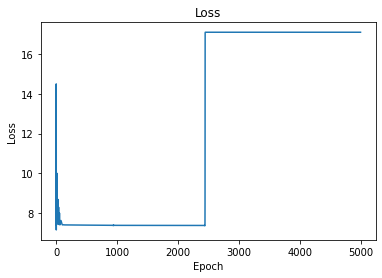

In [35]:
#plot the loss
plt.plot(epoch_loss)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()